In [ ]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import MiniBatchKMeans
from MatrixFactorization import MatrixFactorization as mf
from CollaborativeFiltering import CollaborativeFiltering as cb
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import mean_squared_error


In [ ]:
movie_ratings = pd.read_csv('./dataset/ratings.csv')
movie_ratings_small = pd.read_csv('./dataset/ratings_small.csv')
movies_metadata = pd.read_csv('./dataset/movies_metadata.csv')

<ipython-input-3-54677904f0e3>:3: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  movies_metadata = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/movie_dataset/movies_metadata.csv')


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
movie_ratings_small.head()

,userId,movieId,rating,timestamp
0,1,31,2.5,1260759144
1,1,1029,3.0,1260759179
2,1,1061,3.0,1260759182
3,1,1129,2.0,1260759185
4,1,1172,4.0,1260759205


In [ ]:
movie_ratings.shape, movie_ratings_small.shape

((26024289, 4), (100004, 4))

In [ ]:
movies_metadata = movies_metadata.drop_duplicates(subset='id', keep='first')

In [ ]:
movies_metadata = movies_metadata[movies_metadata['id'].str.isdigit()]
movies_metadata['id'] = movies_metadata['id'].astype('int64')

<ipython-input-7-7420a33fdfa0>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movies_metadata['id'] = movies_metadata['id'].astype('int64')


In [ ]:
# 두 데이터프레임 병합 (movieId 기준)
movies_total= movies_metadata.merge(movie_ratings,
                                        left_on='id',
                                        right_on='movieId',
                                        how='left')

# 필요 없어진 movieId 열 제거
movies_total = movies_total.drop(columns=['movieId'])


In [ ]:
movies_total.shape

(11474436, 27)

In [ ]:
movies_total.dropna(subset='userId', inplace=True)

In [ ]:
movies_total['userId'] = movies_total['userId'].astype('int64')

In [ ]:
a =movies_total[['id','original_title','userId', 'rating']]
a.head()

,id,original_title,userId,rating
0,862,Toy Story,1923,3.0
1,862,Toy Story,2103,5.0
2,862,Toy Story,5380,1.0
3,862,Toy Story,6177,4.0
4,862,Toy Story,6525,4.0


In [ ]:
a.isnull().sum()

,0
id,0
original_title,0
userId,0
rating,0


In [ ]:
user_rating_counts = a.groupby('id').size()
valid_users = user_rating_counts[user_rating_counts >= 5].index
filtered_users = a[a['userId'].isin(valid_users)].reset_index(drop=True)
train, test = train_test_split(filtered_users, test_size= 0.2, random_state = 42)



In [ ]:
train.shape, test.shape

((201614, 4), (50404, 4))

In [ ]:
train.head()

,id,original_title,userId,rating
224303,3160,Furankenshutain Tai Chitei Kaijū Baragon,131478,2.5
182123,300,La science des rêves,7445,5.0
156092,2860,Le genou de Claire,415,5.0
171861,2313,Prime,89623,4.0
194031,2959,License to Wed,47446,3.0


In [ ]:
user_matrix_train = pd.pivot_table(train, index="userId", columns='original_title',values='rating',aggfunc="mean", fill_value=0)
user_matrix_test = pd.pivot_table(test, index="userId", columns='original_title',values='rating',aggfunc="mean", fill_value=0)

In [ ]:
user_matrix_train.shape, user_matrix_test.shape

((5897, 4130), (5080, 2888))

In [ ]:
a = user_matrix_train[user_matrix_train.index == 2]
a.loc[:, (a > 0).any()]

original_title,A Nightmare on Elm Street,Almost Famous,Donnie Darko,Four Rooms,Hable con ella,Interview with the Vampire,Jarhead,La belle et la bête,La passion de Jeanne d'Arc,Monty Python and the Holy Grail,Mrs. Doubtfire,Pirates of the Caribbean: Dead Man's Chest,The Matrix Revolutions,英雄
userId,,,,,,,,,,,,,,
2,4.0,1.0,3.0,3.0,4.0,4.0,3.0,4.0,3.0,3.0,1.0,3.0,4.0,4.0


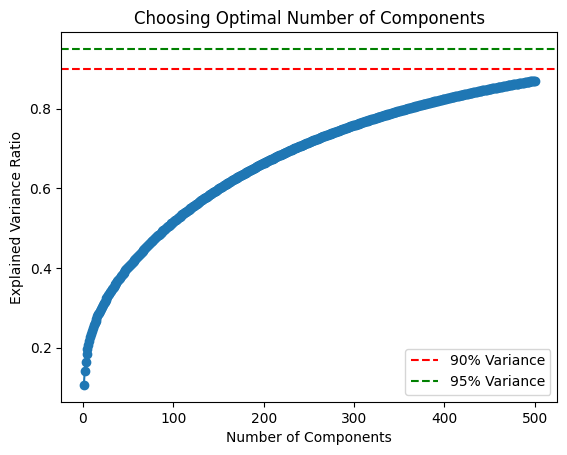

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix
from sklearn.decomposition import TruncatedSVD

# 희소 행렬 변환
user_matrix_sparse = csr_matrix(user_matrix_train)

# SVD 실행
max_components = min(500, min(user_matrix_sparse.shape) - 1)
svd = TruncatedSVD(n_components=max_components, random_state=42)
X_reduced = svd.fit_transform(user_matrix_sparse)

# 설명된 분산 비율 계산
explained_variance_ratio = np.cumsum(svd.explained_variance_ratio_)

# 그래프 그리기
plt.plot(range(1, max_components+1), explained_variance_ratio, marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Explained Variance Ratio')
plt.title('Choosing Optimal Number of Components')
plt.axhline(y=0.90, color='r', linestyle='--', label="90% Variance")
plt.axhline(y=0.95, color='g', linestyle='--', label="95% Variance")
plt.legend()
plt.show()


In [ ]:
print(explained_variance_ratio[::50])  # 50개 단위로 출력

[0.10678348 0.40511345 0.51798395 0.60039252 0.66477153 0.71677342
 0.75950915 0.79508312 0.82487866 0.8498769 ]


In [ ]:
explained_variance_ratio[350]

np.float64(0.7950831190007541)

In [ ]:
mf_ = mf(user_matrix_train)
k_values = [100, 200, 300, 400, 500]  # 실험할 k 값 리스트
for k in k_values:
    actual_items, predicted_items = mf.predict(k, top_k=20)
    precision = mf_.precision_at_k(actual_items, predicted_items, 20)
    recall = mf_.recall_at_k(actual_items, predicted_items, 20)
    print(f"k={k}, Precision: {precision:.4f}, Recall: {recall:.4f}")

k=100, Precision: 0.5211, Recall: 0.5797
k=200, Precision: 0.5795, Recall: 0.6742
k=300, Precision: 0.6027, Recall: 0.7165
k=400, Precision: 0.6153, Recall: 0.7408
k=500, Precision: 0.6228, Recall: 0.7567


In [ ]:
k_values = [100,200, 300, 400, 500]  # 실험할 k 값 리스트
for k in k_values:
    actual_items, predicted_items = mf_.predict(k, top_k=10)
    precision = mf_.precision_at_k(actual_items, predicted_items, 10)
    recall = mf_.recall_at_k(actual_items, predicted_items, 10)
    print(f"k={k}, Precision: {precision:.4f}, Recall: {recall:.4f}")

k=100, Precision: 0.6598, Recall: 0.4613
k=200, Precision: 0.7252, Recall: 0.5432
k=300, Precision: 0.7529, Recall: 0.5814
k=400, Precision: 0.7680, Recall: 0.6040
k=500, Precision: 0.7772, Recall: 0.6182


In [ ]:
max_component = 350

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 53364 (\N{HANGUL SYLLABLE KEUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47084 (\N{HANGUL SYLLABLE REO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 53552 (\N{HANGUL SYLLABLE TEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr

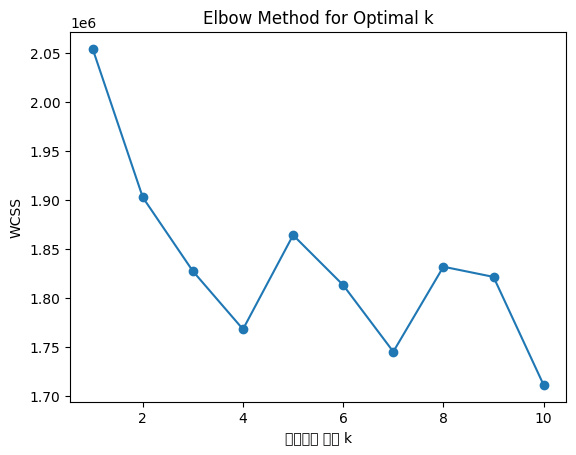

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import TruncatedSVD
from scipy.sparse import csr_matrix

# 희소 행렬로 변환 (User-Item Matrix가 이미 희소 행렬이면 생략 가능)
user_matrix_sparse = csr_matrix(user_matrix_train)
max_components = min(max_component, min(user_matrix_sparse.shape) - 1)

svd = TruncatedSVD(n_components=max_components, random_state=42)
X_reduced = svd.fit_transform(user_matrix_sparse)
batch_size = min(1024, X_reduced.shape[0])  # 배치 크기 최적화
wcss = []
for k in range(1, 11):  # k를 1부터 10까지 테스트
    kmeans = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=batch_size, n_init="auto")
    kmeans.fit(X_reduced)
    wcss.append(kmeans.inertia_)  # inertia_ = WCSS 값

# 그래프 그리기
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('클러스터 개수 k')
plt.ylabel('WCSS')
plt.title('Elbow Method for Optimal k')
plt.show()

In [ ]:
# 특정 사용자에 대해 유사한 사용자를 기반으로 평점 예측, 유사한 사용자가 해당 아이템에 대한 평점이 없으므로 사용자의 평점을 사용함
user_id = 2
n_cluster = 4
movie_name = '장화, 홍련'
user_index = user_matrix_train.index.get_loc(user_id)
cb_ = cb(user_matrix_train, n_clusters=4, k=350)
cb_.clustering()
cb_.calculate_pearson_similarity(user_id)
ratings = cb_.user_based_predict(user_id, movie_name, cb_.user_similarity)
print(f"{movie_name}에 {user_id}의 예상 평점: {ratings}")

장화, 홍련에 2의 예상 평점: 3.142857142857143


In [53]:
user_matrix_train.shape, user_matrix_test.shape

((5897, 4130), (5080, 2888))

In [ ]:
def predict(train_data, test_data):
    predicted_matrix = test_data.copy()
    cb_ = cb(train_data, n_clusters=4, k=350)
    cb_.clustering()

    for user_id in test_data.index:
        if user_id not in train_data.index.values:
            continue  # train_data에 없는 유저는 스킵
        cb_.calculate_pearson_similarity(user_id)
        for movie_name in test_data.columns:
            if movie_name not in train_data.columns:
                continue  # train_data에 없는 영화는 스킵

            if test_data.loc[user_id, movie_name] > 0:
                score = cb_.user_based_predict(user_id, movie_name, cb_.user_similarity)
                predicted_matrix.loc[user_id, movie_name] = score

    return predicted_matrix


In [95]:
predicted = predict(user_matrix_train, user_matrix_test)

In [101]:
mean_squared_error(user_matrix_test, predicted)

0.003367164929247301